In [23]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [24]:
# Define our state 

class Bmicalc(TypedDict):
    weight_kg:float
    height_m: float
    bmi:float
    category:str

In [25]:
# define our function whihc is node actually 
def calculate_bmi(state:Bmicalc)->Bmicalc:
    weight=state['weight_kg']
    height=state['height_m']
    bmi=weight/(height**2)

    state['bmi']=round(bmi,2)

    return state

In [26]:
# define our another node for category 
def category(state:Bmicalc)->Bmicalc:
    bmi=state['bmi']

    if bmi<18.5:
        state["category"]="Underweight"

    elif 18.5 <=bmi <25:
        state['category']="Normal"

    elif 25<= bmi <30:
        state["category"]='Overweight'

    else:
        state['category']='Obse'

    return state

In [35]:
# define our graph 
graph=StateGraph(Bmicalc)

# adding node to graph 

graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node("Category",category)

# add edges to graph 
graph.add_edge(START,"calculate_bmi"),
graph.add_edge("calculate_bmi","Category")
graph.add_edge("Category",END)

# compile the graph 
workflow=graph.compile()

# Initial state
initial_state={
    'weight_kg':85,
    'height_m':1.8
}

final_state=workflow.invoke(initial_state)

In [36]:
print(final_state)

{'weight_kg': 85, 'height_m': 1.8, 'bmi': 26.23, 'category': 'Overweight'}


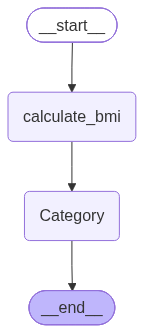

In [30]:
from IPython.display import Image, display

# Draw the graph as PNG
png = workflow.get_graph().draw_mermaid_png()

# Display the image in Jupyter
display(Image(png))

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	calculate_bmi(calculate_bmi)
	__end__([<p>__end__</p>]):::last
	__start__ --> calculate_bmi;
	calculate_bmi --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	calculate_bmi(calculate_bmi)
	__end__([<p>__end__</p>]):::last
	__start__ --> calculate_bmi;
	calculate_bmi --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

